In [9]:
import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F



# =========================================================
# CONFIGURATION
# =========================================================
DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED_1s"

SAMPLE_RATE  = 8000
N_MELS       = 128
FMAX         = 1000

TARGET_T     = 200      # <---- FIXED WIDTH RESOLUTION (prevents OOM)
BATCH_SIZE   = 32
EPOCHS       = 10

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)



# =========================================================
# CNN MODEL
# =========================================================
class FishCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.gap   = nn.AdaptiveAvgPool2d((8, 8))

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.drop = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return F.log_softmax(self.fc2(x), dim=1)



# =========================================================
# MEL SPECTROGRAM + RESIZING (CRITICAL FIX)
# =========================================================
def extract_mel(path):
    y, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, fmax=FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # ---- Resize to (128, TARGET_T) ----
    mel_tensor = torch.tensor(mel_db).unsqueeze(0).unsqueeze(0)  # (1,1,128,T)
    mel_resized = F.interpolate(
        mel_tensor,
        size=(N_MELS, TARGET_T),
        mode="bilinear",
        align_corners=False
    )
    return mel_resized.squeeze(0).squeeze(0).float()   # (128, T)



# =========================================================
# LABEL MAPPING THAT WORKS FOR 1S + 5S STRUCTURE
# =========================================================
def map_label(path):
    parts = path.lower().split(os.sep)

    for p in parts:
        if "background" in p:
            return "background"
        if "pre" in p and "feed" in p:
            return "pre-feeding"
        if "post" in p and "feed" in p:
            return "post-feeding"
        if "feeding" in p:
            return "feeding"
    return None



# =========================================================
# LOAD DATASET
# =========================================================
files, labels = [], []

for root, dirs, fs in os.walk(DATASET_PATH):
    for f in fs:
        if f.endswith(".wav"):
            full_path = os.path.join(root, f)
            lbl = map_label(root)
            if lbl:
                files.append(full_path)
                labels.append(lbl)

print("Total samples:", len(files))
print("Classes:", set(labels))



# =========================================================
# ENCODE LABELS
# =========================================================
le = LabelEncoder()
y = le.fit_transform(labels)



# =========================================================
# TRAIN/TEST SPLIT
# =========================================================
train_files, test_files, y_train, y_test = train_test_split(
    files, y, test_size=0.2, random_state=42, stratify=y
)



# =========================================================
# DATASET CLASS
# =========================================================
class MelDataset(Dataset):
    def __init__(self, filepaths, labels):
        self.f = filepaths
        self.y = labels

    def __getitem__(self, idx):
        mel = extract_mel(self.f[idx])   # (128, TARGET_T)
        mel = mel.unsqueeze(0)           # (1,128,T)
        return mel, torch.tensor(self.y[idx], dtype=torch.long)

    def __len__(self):
        return len(self.f)



# =========================================================
# DATALOADERS
# =========================================================
train_dl = DataLoader(
    MelDataset(train_files, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dl = DataLoader(
    MelDataset(test_files, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)



# =========================================================
# TRAINING SETUP
# =========================================================
model = FishCNN().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()



# =========================================================
# TRAINING LOOP
# =========================================================
print("\nTraining...\n")
start = time.time()

for epoch in range(EPOCHS):
    model.train()
    running = 0

    for mel, label in train_dl:
        mel, label = mel.to(DEVICE), label.to(DEVICE)

        optimizer.zero_grad()
        out = model(mel)
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()

        running += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss={running/len(train_dl):.4f}")

train_time = time.time() - start



# =========================================================
# EVALUATION
# =========================================================
model.eval()
y_true, y_pred = [], []

start_inf = time.time()

with torch.no_grad():
    for mel, label in test_dl:
        mel = mel.to(DEVICE)
        preds = model(mel).argmax(1).cpu().numpy()

        y_true.extend(label.numpy())
        y_pred.extend(preds)

inf_time = (time.time() - start_inf) / len(test_dl)



# =========================================================
# METRICS
# =========================================================
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")
f1   = f1_score(y_true, y_pred, average="macro")
cm   = confusion_matrix(y_true, y_pred)

print("\n--- FINAL RESULTS (1s + 5s) ---")
print("Training time:", round(train_time, 2), "s")
print("Inference time/sample:", round(inf_time*1000, 3), "ms")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print(cm)



# =========================================================
# CONFUSION MATRIX PLOT
# =========================================================
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - CNN (1s + 5s Combined)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Using device: cuda
Total samples: 0
Classes: set()


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

Loaded samples: 24000
Classes: {'pre-feeding', 'background', 'post-feeding', 'feeding'}

Training SVM...
Training time: 50.83 s

--- SNR ROBUSTNESS TEST ---
SNR 30 dB → F1-score: 0.6272
SNR 20 dB → F1-score: 0.5572
SNR 10 dB → F1-score: 0.3859
SNR 5 dB → F1-score: 0.2971
SNR 0 dB → F1-score: 0.2775


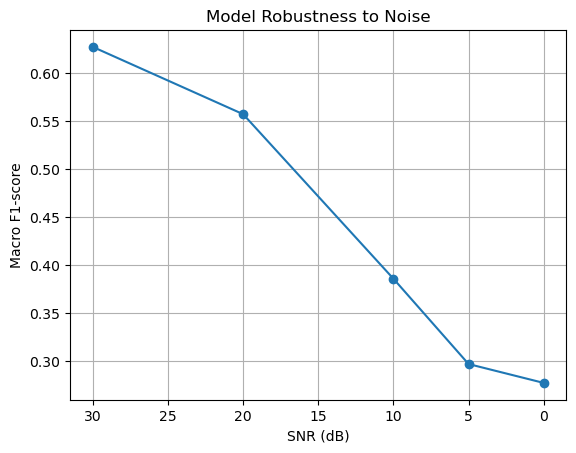

In [1]:
import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED/Segmented_1s"
SAMPLE_RATE = 8000
N_MELS = 128
SNR_LEVELS = [30, 20, 10, 5, 0]


# ---------------------------------------------------------
# LABEL MAPPING
# ---------------------------------------------------------
def map_label_from_path(path):
    p = path.lower()

    if "background" in p:
        return "background"
    if "pre" in p and "feed" in p:
        return "pre-feeding"
    if "post" in p and "feed" in p:
        return "post-feeding"
    if "feeding" in p:
        return "feeding"

    return None


# ---------------------------------------------------------
# FEATURE EXTRACTION
# ---------------------------------------------------------
def extract_features(y):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE, n_mels=N_MELS, fmax=1000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    contrast = librosa.feature.spectral_contrast(
        y=y, sr=SAMPLE_RATE, fmin=50, n_bands=6
    )

    return np.concatenate([mel_db.flatten(), contrast.flatten()])


# ---------------------------------------------------------
# ADD NOISE AT TARGET SNR
# ---------------------------------------------------------
def add_noise_at_snr(signal, snr_db):
    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)

    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)

    return signal + noise


# ---------------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------------
X = []
y = []
file_paths = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            label = map_label_from_path(root)
            if label is None:
                continue

            signal, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

            features = extract_features(signal)

            X.append(features)
            y.append(label)
            file_paths.append(file_path)

X = np.array(X)
y = np.array(y)

print("Loaded samples:", len(X))
print("Classes:", set(y))


# ---------------------------------------------------------
# ENCODE + SCALE
# ---------------------------------------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ---------------------------------------------------------
# TRAIN / TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X_scaled, y_encoded, file_paths,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# ---------------------------------------------------------
# TRAIN SVM
# ---------------------------------------------------------
svm = SVC(kernel="rbf")

print("\nTraining SVM...")
start = time.time()
svm.fit(X_train, y_train)
print("Training time:", round(time.time() - start, 2), "s")


# ---------------------------------------------------------
# SNR ROBUSTNESS TEST
# ---------------------------------------------------------
f1_scores = []

print("\n--- SNR ROBUSTNESS TEST ---")

for snr in SNR_LEVELS:
    X_noisy = []

    for path in paths_test:
        signal, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)

        # Add noise
        noisy_signal = add_noise_at_snr(signal, snr)

        # Extract features
        features = extract_features(noisy_signal)
        X_noisy.append(features)

    X_noisy = np.array(X_noisy)
    X_noisy = scaler.transform(X_noisy)

    # Predict
    y_pred = svm.predict(X_noisy)

    f1 = f1_score(y_test, y_pred, average="macro")
    f1_scores.append(f1)

    print(f"SNR {snr} dB → F1-score: {f1:.4f}")


# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------
plt.figure()

plt.plot(SNR_LEVELS, f1_scores, marker='o')

plt.xlabel("SNR (dB)")
plt.ylabel("Macro F1-score")
plt.title("Model Robustness to Noise")

plt.gca().invert_xaxis()  # 30 → 0 dB (clean → noisy)
plt.grid(True)

plt.savefig("snr_robustness.png", dpi=300, bbox_inches="tight")
plt.show()